# 注意力其实很稀疏：块稀疏入门

FlashAttention 把 full 注意力做到了又快又省显存，但计算量仍是 $O(S^2)$——每个 query 都要和每个 key 算一遍。
可你若真看一眼注意力矩阵会发现：**大部分权重集中在少数几段上下文**，其余几乎是零。那为什么还要全算？

这一章走进**块稀疏注意力**：把 key 切成块，每个 query 块只挑**最相关的 top-$k$ 个 key 块**来算。这是 DeepSeek
NSA 等方法的核心地基。我们先用纯 PyTorch 把"选块 + 稀疏算"的机制讲透（§1–§4），再去读真正的稀疏 Triton kernel
（§5，复用第 08 章 NSA 的实现）。

In [1]:
import sys, math
from pathlib import Path

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

ROOT = Path.cwd()
while not (ROOT / "common").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
CH = ROOT / "07-block-sparse-attention"
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(CH))

from common import make_qkv, naive_attention, bench_ms
from common.nbtools import setup_cjk, show_code
setup_cjk()                                       # 中文字体 + retina 高清出图
from block_sparse import select_topk_blocks, block_sparse_reference, block_sparse_attention, _pool_blocks

torch.manual_seed(0)
print("跑在", torch.cuda.get_device_name(0))

跑在 NVIDIA GeForce RTX 4090


## 1. 先亲眼看看：注意力到底有多稀疏

因果注意力把 query $q_i$ 对所有 $j\le i$ 的 key 算 $\operatorname{softmax}$ 权重 $a_{ij}=\dfrac{\exp(q_i^\top k_j/\sqrt d)}{\sum_{j'\le i}\exp(q_i^\top k_{j'}/\sqrt d)}$。
softmax 的指数让权重高度集中：少数 $j$ 占了几乎全部质量。我们把注意力矩阵画出来，再统计每个 query "真正在意"的 key 有多少。

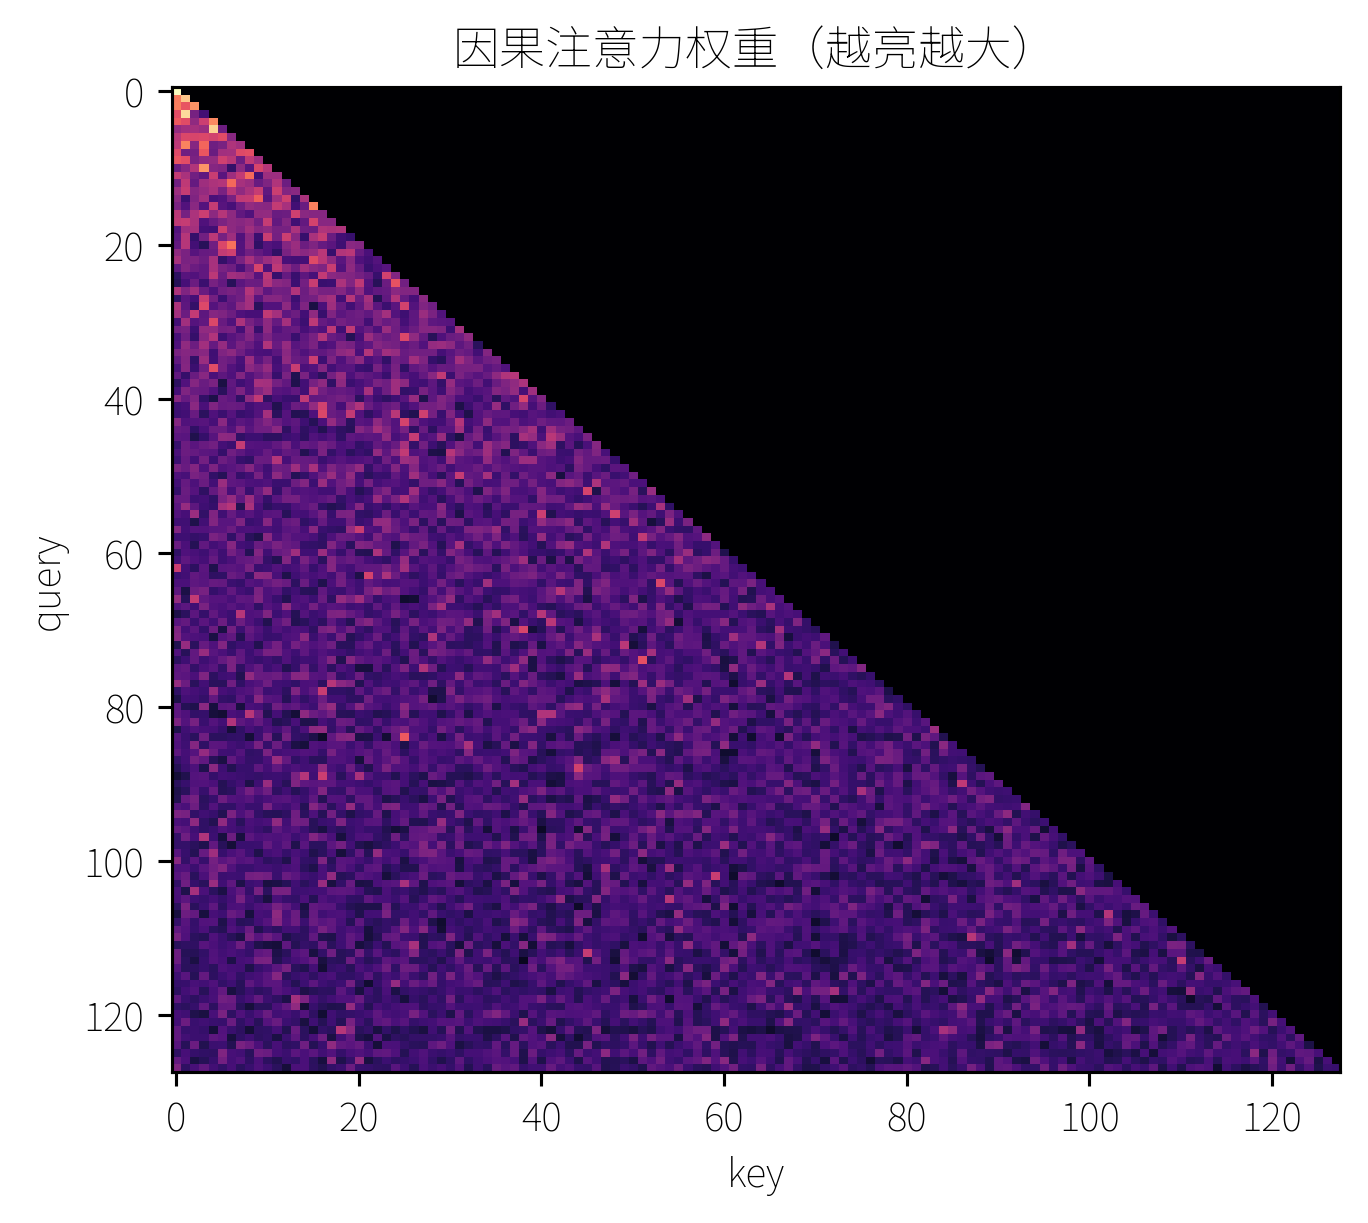

平均每个 query 累计 90% 注意力只需 40 个 key（共最多 128 个可见）——其余几乎是零。


In [2]:
q, k, v = make_qkv(1, 1, 128, 64, dtype=torch.float16, seed=0)
scores = (q.float() @ k.float().transpose(-1, -2)) / math.sqrt(64)
S = q.shape[2]
scores = scores.masked_fill(~torch.ones(S, S, device=q.device).tril().bool(), float("-inf"))
attn = torch.softmax(scores, dim=-1)[0, 0]      # (S,S)

plt.figure(figsize=(5, 4.5))
plt.imshow(attn.cpu().float().pow(0.3), cmap="magma", aspect="auto")  # ^0.3 提亮，便于看清
plt.title("因果注意力权重（越亮越大）"); plt.xlabel("key"); plt.ylabel("query")
plt.tight_layout(); plt.show()

# 每个 query：要累计到 90% 权重，平均需要多少个 key？
sorted_w = attn.sort(dim=-1, descending=True).values
cum = sorted_w.cumsum(-1)
need = (cum < 0.9).sum(-1).float() + 1          # 达到 90% 权重所需的 key 数
print(f"平均每个 query 累计 90% 注意力只需 {need.mean():.0f} 个 key（共最多 {S} 个可见）——其余几乎是零。")

## 2. 三步：分块取代表 → 块级 top-$k$ 选块 → 只算选中块

既然注意力这么稀疏，那就别全算。把序列切成大小 $B$ 的块（共 $n_b=S/B$ 块），做三步：

**① 分块取代表**：每块取均值，得到块的"代表向量"——

$$\bar q_a=\frac1B\sum_{i\in\text{块}a}q_i,\qquad \bar k_b=\frac1B\sum_{j\in\text{块}b}k_j.$$

**② 块级重要性 + top-$k$ 选块**：用代表向量两两打分得块级重要性矩阵，每个 query 块选最相关的 top-$k$ 个 key 块——

$$I_{ab}=\frac{\bar q_a^\top \bar k_b}{\sqrt d}\quad(\text{causal: }b\le a),\qquad \mathcal S(a)=\operatorname{top\text{-}k}_b\,I_{ab}.$$

**③ 稀疏计算**：只对选中的块 $\mathcal S(a)$ 算注意力，计算量从 $O(n_b^2)$ 个块降到 $O(n_b\cdot k)$ 个块。

第②步是灵魂。下面把"块级重要性矩阵"和"最终选中的块"并排画出来：

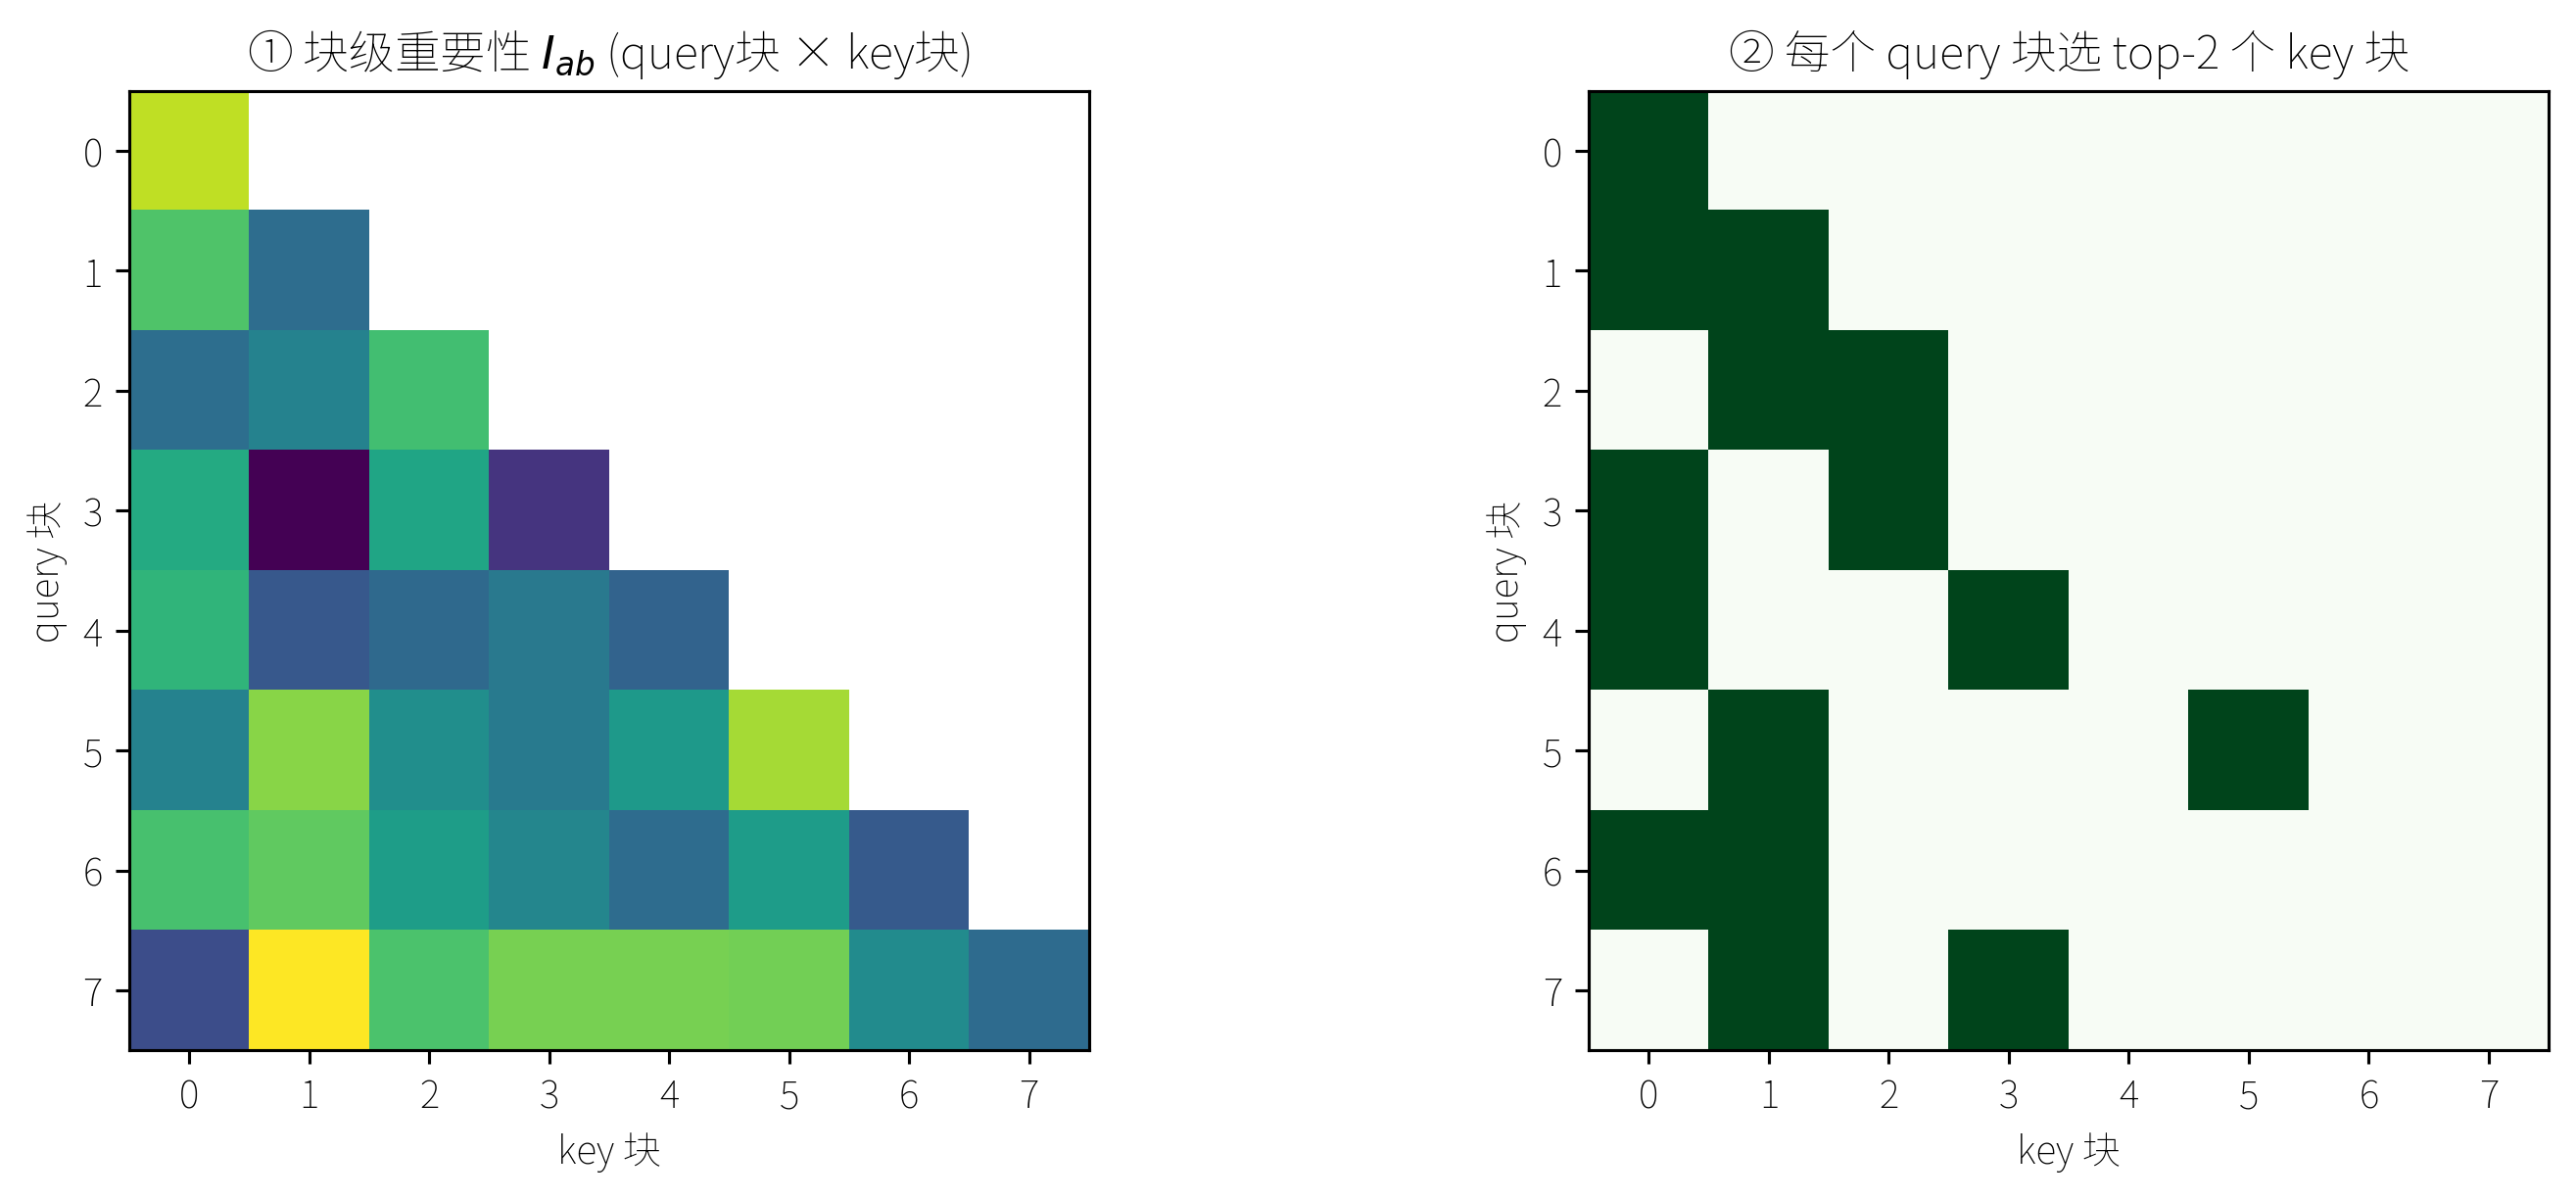

右图每行只有 2 个绿格——8 个 key 块里只算这 2 个，其余跳过。计算量 O(nb²)→O(nb·top_k)。


In [3]:
q, k, v = make_qkv(1, 1, 256, 64, dtype=torch.float16, seed=1)
block_size, top_k = 32, 2
nb = 256 // block_size

q_blk, k_blk = _pool_blocks(q, block_size), _pool_blocks(k, block_size)
imp = (q_blk.float() @ k_blk.float().transpose(-1, -2) / math.sqrt(64))[0, 0]   # (nb,nb)
causal = torch.ones(nb, nb, device=q.device).tril().bool()
imp_vis = imp.masked_fill(~causal, float("nan"))

idx = select_topk_blocks(q, k, block_size, top_k, causal=True)[0, 0]            # (nb, top_k)
sel = torch.zeros(nb, nb, dtype=torch.bool, device=q.device)
sel.scatter_(1, idx, True); sel &= causal

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
ax1.imshow(imp_vis.cpu().float(), cmap="viridis"); ax1.set(title="① 块级重要性 $I_{ab}$ (query块 × key块)", xlabel="key 块", ylabel="query 块")
ax2.imshow(sel.cpu().float(), cmap="Greens"); ax2.set(title=f"② 每个 query 块选 top-{top_k} 个 key 块", xlabel="key 块", ylabel="query 块")
plt.tight_layout(); plt.show()
print(f"右图每行只有 {top_k} 个绿格——{nb} 个 key 块里只算这 {top_k} 个，其余跳过。计算量 O(nb²)→O(nb·top_k)。")

## 3. 两条等价路径：mask 参考 vs gather 省算

`block_sparse.py` 把三步实现成两条等价路径：

- `block_sparse_reference`：把块选择展开成 token 级 mask，再做一次 **full 注意力**（ground truth，能清楚"看见"哪些块被选，但不省计算）；
- `block_sparse_attention`：**gather** 出每个 query 块选中的 key/value 块，**只对它们**算注意力（真正省计算，全程向量化）。

验证两点：(a) gather 省算实现必须和 mask 参考**数值一致**；(b) 当 top-$k$ 取满（选中所有可见块）时，块稀疏必须**退化为 full 注意力**。

In [4]:
q, k, v = make_qkv(2, 4, 512, 64, dtype=torch.float16, seed=2)
nb = 512 // 64

for tk in [1, 2, 4]:                                  # (a) gather ≡ reference
    ref = block_sparse_reference(q, k, v, 64, tk, causal=True)
    gat = block_sparse_attention(q, k, v, 64, tk, causal=True)
    print(f"top_k={tk}: gather vs mask参考 最大差异 {(ref-gat).abs().max().item():.1e}  ✓")

full = naive_attention(q, k, v, causal=True)          # (b) 全选 ≡ full
allsel = block_sparse_reference(q, k, v, 64, top_k=nb, causal=True)
print(f"\ntop_k={nb}(全选) vs full 注意力 最大差异 {(full-allsel).abs().max().item():.1e}  ✓ 退化为 full")

top_k=1: gather vs mask参考 最大差异 0.0e+00  ✓
top_k=2: gather vs mask参考 最大差异 2.4e-04  ✓
top_k=4: gather vs mask参考 最大差异 2.4e-04  ✓

top_k=8(全选) vs full 注意力 最大差异 0.0e+00  ✓ 退化为 full


## 4. 对照：MoBA 的另一种选块

块稀疏的"怎么选块"有不同设计。本章的实现用**块均值代表 + top-$k$**；**MoBA**（Mixture of Block Attention，Moonshot）
是另一条生产路线，思路相近但两处不同（实现见 `moba_naive.py`）：

| | 本章 block-sparse | MoBA |
|---|---|---|
| 块代表 | 块内**均值** $\bar k_b$ | 块内**均值** $\bar k_b$（同） |
| 选块打分 | $\bar q_a^\top\bar k_b$，causal $b\le a$ | $q_i^\top\bar k_b$（**逐 token** 打分，非逐块） |
| 当前块 | 按 top-$k$ 选 | **当前块恒选**（保证看到最近上下文）+ 块内严格 causal |
| 路由粒度 | query 块 → key 块 | query token → key 块 |

两者都是"块代表打分 + top-$k$ 选块"的稀疏注意力；差别在路由粒度（逐块 vs 逐 token）与当前块的处理。NSA（下一章）则
更进一步——把块代表换成**可学习的压缩**，并加压缩/滑窗分支。

## 5. 逐段精读：gather 省算的稀疏算子

§3 的 `block_sparse_attention` 是稀疏计算真正发生的地方。逐段看它怎么 gather 选中块、只算选中块。

```python
# block_sparse.py · block_sparse_attention（节选）
topk_idx = select_topk_blocks(q, k, block_size, top_k, causal=causal)   # ① 选块：(B,H,nb,kk)
k_blocks = k.view(B, H, nb, block_size, D)                              # 把 K/V 按块 reshape
idx = topk_idx[..., None, None].expand(B, H, nb, kk, block_size, D)
k_sel = torch.gather(k_blocks[:, :, None].expand(...), 3, idx)          # ② gather 出选中的 kk 个 key 块
k_sel = k_sel.reshape(B, H, nb, kk * block_size, D)                     #    → 每个 query 块只配 kk·B 个 key
scores = torch.einsum("bhnqd,bhnkd->bhnqk", q_blk, k_sel) * sm_scale    # ③ 只在选中块上算注意力
# causal：选中块在序列里的全局位置由 topk_idx 决定，据此构造 token 级 causal mask
attn = torch.softmax(scores, dim=-1)
out = torch.einsum("bhnqk,bhnkd->bhnqd", attn, v_sel)                   # ④ 加权求和
```

四步对应 §2 的三步机制：① top-$k$ 选块；② `gather` 把选中的 $kk$ 个 key/value 块取出来（这是"省算"的关键——
后面只对 $kk\cdot B$ 个 key 算，而非全部 $S$ 个）；③④ 在选中块上做标准的 $\operatorname{softmax}$ 注意力。`reference`
路径则相反——展开成 $S\times S$ 的 token mask 走 full 注意力，只为对照正确性。

> **深度优化版**：07 的"动态 top-$k$ 块稀疏"正是 NSA 的 **selected 分支**。`block_sparse_triton.py` **不另造 kernel**，
> 直接复用第 08 章已提取并验证的 `nsa_triton.native_sparse_attend`（来源 lucidrains NSA）。真正的稀疏 Triton kernel
> 在 08 章逐段精读。

### 完整源码（供查阅全貌）

本章自写机制版 `block_sparse.py` 的完整源码（可滚动）——分块代表 `_pool_blocks`、选块 `select_topk_blocks`、两条路径
`block_sparse_reference` / `block_sparse_attention` 都在这里：

In [5]:
show_code(str(CH / "block_sparse.py"))

## 6. 省了多少？以及为什么还需要稀疏 kernel

块稀疏只算选中块，top-$k$ 越小越快。但纯 PyTorch 的 `gather`/`scatter` 有开销，和**融合**的 SDPA 比并不占便宜——
这正是为什么"既稀疏又快"必须把"选块 + 稀疏算"焊进一个 Triton kernel（第 08 章）。看数据：

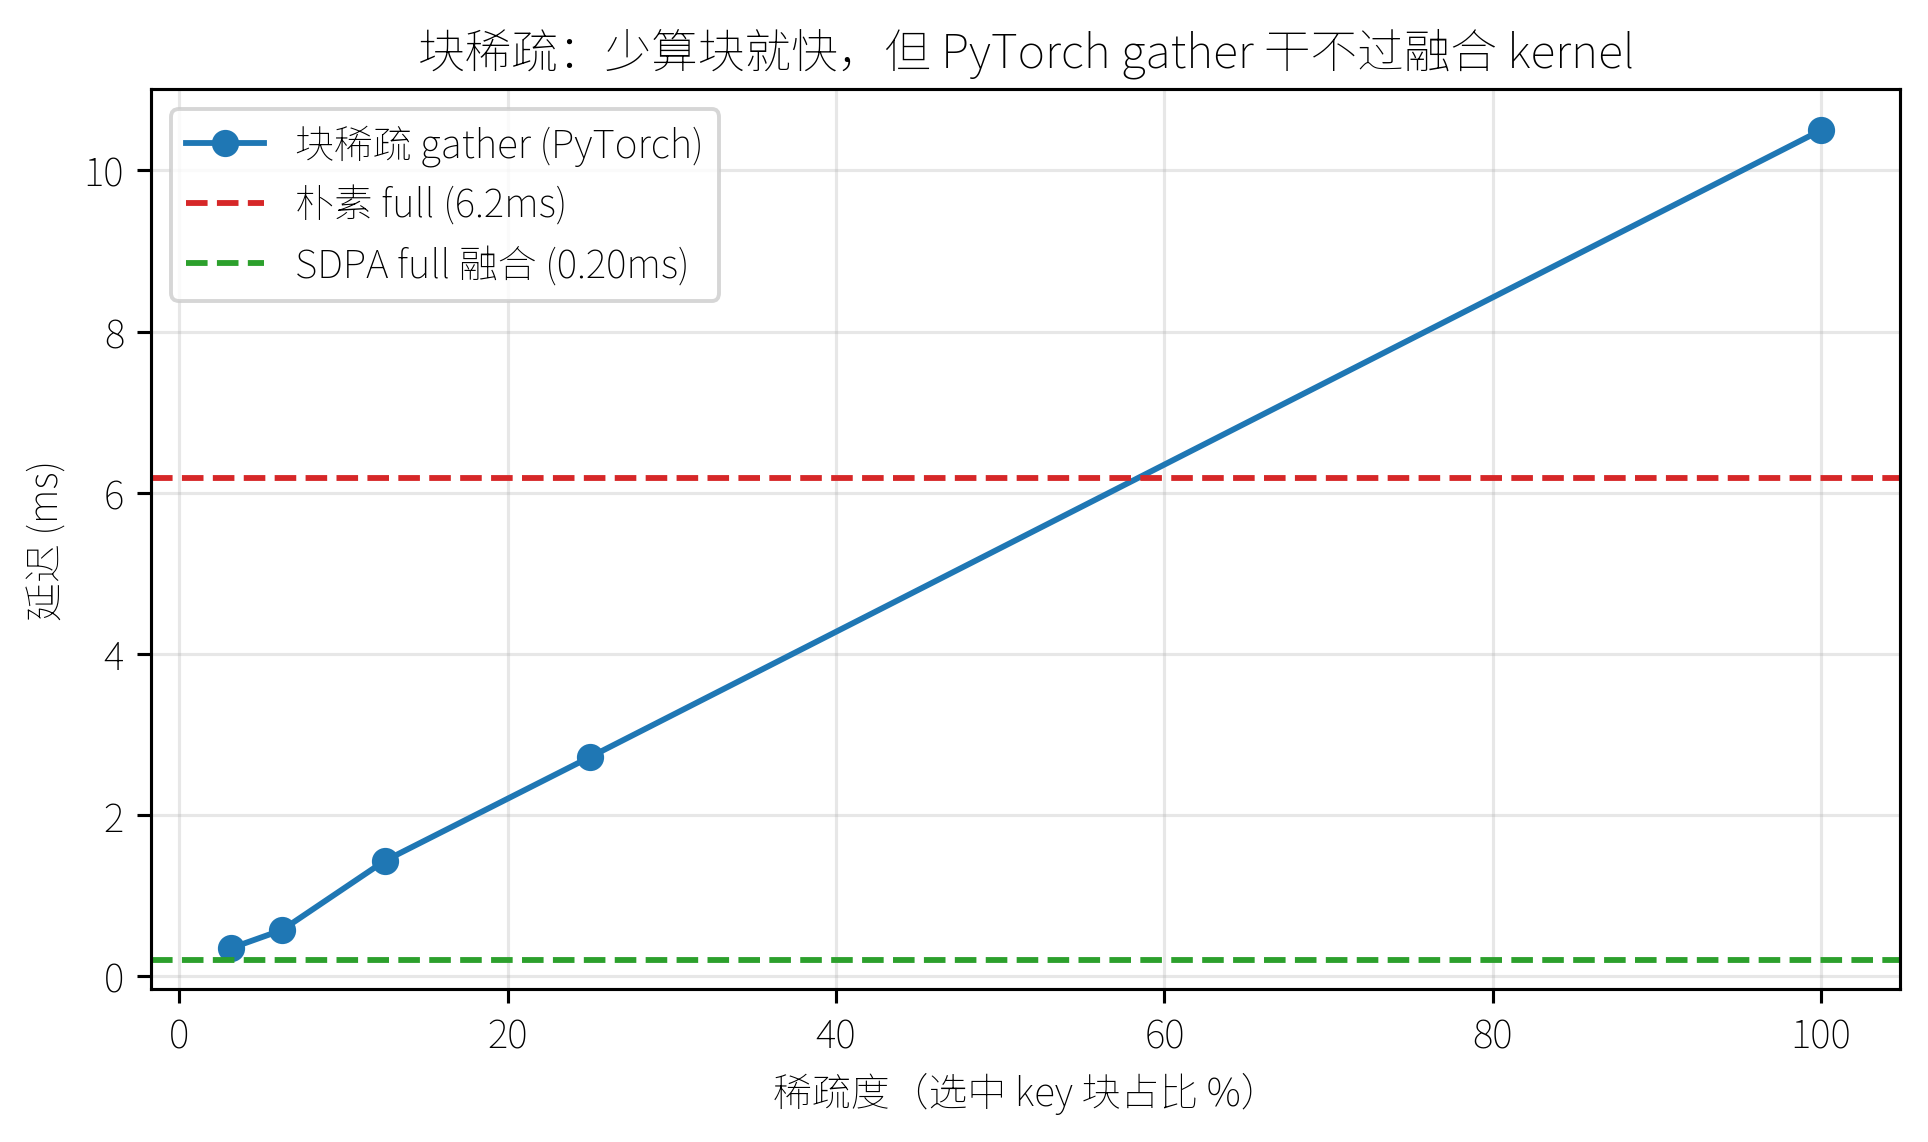

选 2/32 块(6%): 0.58ms，比朴素 full 快 11×，但仍慢于 SDPA 的 0.20ms。


In [6]:
S, block_size, nb = 2048, 64, 32
q, k, v = make_qkv(4, 8, S, 64, dtype=torch.float16, seed=0)
ms_naive = bench_ms(lambda: naive_attention(q, k, v, causal=True))
ms_sdpa = bench_ms(lambda: F.scaled_dot_product_attention(q, k, v, is_causal=True))

tks = [1, 2, 4, 8, nb]
lat = [bench_ms(lambda tk=tk: block_sparse_attention(q, k, v, block_size, tk, causal=True)) for tk in tks]

plt.figure(figsize=(7, 4.2))
plt.plot([t / nb * 100 for t in tks], lat, "o-", label="块稀疏 gather (PyTorch)")
plt.axhline(ms_naive, ls="--", c="C3", label=f"朴素 full ({ms_naive:.1f}ms)")
plt.axhline(ms_sdpa, ls="--", c="C2", label=f"SDPA full 融合 ({ms_sdpa:.2f}ms)")
plt.xlabel("稀疏度（选中 key 块占比 %）"); plt.ylabel("延迟 (ms)"); plt.legend(); plt.grid(alpha=0.3)
plt.title("块稀疏：少算块就快，但 PyTorch gather 干不过融合 kernel")
plt.tight_layout(); plt.show()
print(f"选 2/{nb} 块(6%): {lat[1]:.2f}ms，比朴素 full 快 {ms_naive/lat[1]:.0f}×，但仍慢于 SDPA 的 {ms_sdpa:.2f}ms。")

## 🛠 动手练习

1. **稀疏度 ↔ 精度曲线**：扫 `top_k` 从 1 到 `nb`（全选），画出"输出 vs full 注意力的误差"随稀疏度的变化，找到精度开始
   明显下降的拐点——这就是"能省多少"的边界。
2. **块粒度的影响**：把 `block_size` 改大（如 128）或改小（如 16），看选块粒度对精度和（gather）速度的影响。块越大越省路由
   开销，但选择越粗。

## 7. 收尾

- 注意力天然**稀疏**：softmax 让每个 query 的权重集中在少数块上，全算是浪费；
- 块稀疏三步——**分块取代表 $\bar q,\bar k$ → 块级 top-$k$ 选块 $\mathcal S(a)$ → 只算选中块**——把计算量按块数从 $O(n_b^2)$ 砍到 $O(n_b k)$；
- 两条路径（mask 参考 / gather 省算）验证了机制，MoBA 是同类思路的另一种路由；
- 但纯 PyTorch 的 gather/scatter 开销，让它干不过融合的 SDPA——**要既稀疏又快，必须把"选块 + 稀疏算"焊进一个 Triton kernel**。

**下一站** → `08-native-sparse-attention`：DeepSeek 的 NSA 把"压缩 + 选择 + 滑窗"三条稀疏分支门控合并，并用真正的稀疏
Triton kernel 实现——我们去逐段读它（07 的深度优化版正是复用它的 selected 分支）。